# 02 — Training: Layer 2 (Macro Topic) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 2 — Macro Topic (5 classes, post-merge) |
| **Notebook role** | Fine-tuning only |
| **Owner** | Thrithwaka |
| **Upstream input** | `data/splits/layer2/train.csv` (oversampled), `val.csv` (untouched) |
| **Downstream consumer** | `03_evaluation.ipynb` |
| **Base model** | `xlm-roberta-base`, 5-way classification head |
| **Random seed** | 42 |
| **Environment** | Google Colab with GPU runtime, project on Google Drive |

## Purpose

Fine-tunes `xlm-roberta-base` on the merged 5-class Layer 2 taxonomy
(`TOPIC_ECON_SERV`, `TOPIC_GOV`, `TOPIC_LAW`, `TOPIC_FOR`, `TOPIC_MEDIA`), using
`text_clean` (Unicode-normalized text) as model input — not `text_raw` — per the
corrected `01_data_preparation.ipynb`. Does not touch `test.csv`.

## How to Read This Notebook

No claim of 100% accuracy anywhere in this pipeline. Per-class metrics reported
throughout, critical here since `TOPIC_GOV` alone is ~74% of the training data even after
merging — aggregate accuracy would hide weak performance on every other class.

## 1. Google Colab Setup — Environment & Google Drive

1. **Runtime → Change runtime type → GPU** first.
2. Run the install cell, then restart exactly as instructed.

In [ ]:
!pip uninstall -y torchvision torchaudio -q
!pip install -q transformers==4.53.0 datasets accelerate sentencepiece "scikit-learn>=1.4"
print("Install complete. REQUIRED: Runtime -> Restart session, then Runtime -> Run all.")

Install complete. REQUIRED: Runtime -> Restart session, then Runtime -> Run all.


**Stop here and restart the runtime now**, then **Runtime → Run all**.

In [ ]:
import torch
import transformers

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
assert transformers.__version__ == "4.53.0", "Did you Restart session after the install cell?"

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
print("Core imports successful -- no torchvision conflict.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nDevice:", device)
if device == "cpu":
    print("WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU and re-run.")

torch: 2.11.0+cu128
transformers: 4.53.0
Core imports successful -- no torchvision conflict.

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/public-pulse-srilanka")
assert PROJECT_ROOT.exists(), f"Project folder not found at {PROJECT_ROOT}."
print("Project root:", PROJECT_ROOT.resolve())

Mounted at /content/drive
Project root: /content/drive/MyDrive/public-pulse-srilanka


In [ ]:
splits_check = PROJECT_ROOT / "data" / "splits" / "layer2"
weights_check = PROJECT_ROOT / "models" / "layer2_topic" / "class_weights.json"
print("train.csv exists:", (splits_check / "train.csv").exists())
print("class_weights.json exists:", weights_check.exists())
if not (splits_check / "train.csv").exists():
    print("WARNING: run the updated 01_data_preparation.ipynb first -- this expects text_clean and the 5-class merged taxonomy.")

train.csv exists: True
class_weights.json exists: True


## 2. Setup, Imports & Reproducibility

In [ ]:
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import DataCollatorWithPadding, set_seed
from sklearn.metrics import classification_report, confusion_matrix, f1_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
set_seed(RANDOM_STATE)

SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer2"
MODEL_DIR = PROJECT_ROOT / "models" / "layer2_topic"
CHECKPOINTS_DIR = MODEL_DIR / "checkpoints"
RUN_OUTPUT_DIR = MODEL_DIR / "_training_run"
RESULTS_TRAINING_DIR = PROJECT_ROOT / "results" / "training_curves"
RESULTS_CM_DIR = PROJECT_ROOT / "results" / "confusion_matrices"

for d in [CHECKPOINTS_DIR, RUN_OUTPUT_DIR, RESULTS_TRAINING_DIR, RESULTS_CM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "xlm-roberta-base"
MAX_SEQ_LENGTH = 256
EXPECTED_LABEL_COUNT = 5  # post-merge: GOV, LAW, FOR, MEDIA, ECON_SERV

## 3. Load Prepared Data

**Model input is `text_clean`, not `text_raw`** — the corrected data-prep notebook's
Unicode-normalized, whitespace-cleaned text. `text_raw` is still present in the file for
human reference only.

In [ ]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")

LAYER2_LABELS = sorted(train_df["layer2_topic_label"].unique())

print(f"Train: {len(train_df)} rows (oversampled)")
print(f"Val:   {len(val_df)} rows (untouched)")
print("Classes found:", LAYER2_LABELS)
print()
print(train_df["layer2_topic_label"].value_counts())

assert "text_clean" in train_df.columns, "text_clean missing -- did you run the updated 01_data_preparation.ipynb?"
assert train_df["layer2_topic_label"].isna().sum() == 0
assert len(LAYER2_LABELS) == EXPECTED_LABEL_COUNT, (
    f"Expected {EXPECTED_LABEL_COUNT} classes (post-merge), found {len(LAYER2_LABELS)}: {LAYER2_LABELS}"
)
for leaked_col in ["layer1_utility_label", "layer3_subissue_label", "layer4_stance_label", "is_sarcastic"]:
    assert leaked_col not in train_df.columns, f"{leaked_col} should not be present -- column scoping contract broken"
print("\nUpstream data contract verified: 5 classes, text_clean present, no cross-layer leakage.")

Train: 6033 rows (oversampled)
Val:   1153 rows (untouched)
Classes found: ['TOPIC_ECON_SERV', 'TOPIC_FOR', 'TOPIC_GOV', 'TOPIC_LAW', 'TOPIC_MEDIA']

layer2_topic_label
TOPIC_GOV          4433
TOPIC_LAW           400
TOPIC_FOR           400
TOPIC_MEDIA         400
TOPIC_ECON_SERV     400
Name: count, dtype: int64

Upstream data contract verified: 5 classes, text_clean present, no cross-layer leakage.


## 4. Label Encoding

In [ ]:
label2id = {label: idx for idx, label in enumerate(LAYER2_LABELS)}
id2label = {idx: label for label, idx in label2id.items()}

with open(MODEL_DIR / "label_map.json", "w") as f:
    json.dump(label2id, f, indent=2)

print("Label map:", label2id)
train_df["label"] = train_df["layer2_topic_label"].map(label2id)
val_df["label"] = val_df["layer2_topic_label"].map(label2id)

Label map: {'TOPIC_ECON_SERV': 0, 'TOPIC_FOR': 1, 'TOPIC_GOV': 2, 'TOPIC_LAW': 3, 'TOPIC_MEDIA': 4}


## 5. Tokenization & Dataset Construction (on `text_clean`)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text_clean"],   # NOT text_raw -- see Section 3
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    )

train_dataset = Dataset.from_pandas(train_df[["text_clean", "label"]].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[["text_clean", "label"]].reset_index(drop=True))

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

print(train_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6033 [00:00<?, ? examples/s]

Map:   0%|          | 0/1153 [00:00<?, ? examples/s]

Dataset({
    features: ['text_clean', 'label', 'input_ids', 'attention_mask'],
    num_rows: 6033
})


## 6. Load Class Weights

Already correctly computed post-oversampling in `01_data_preparation.ipynb` — loaded
directly, no recomputation needed.

In [ ]:
with open(MODEL_DIR / "class_weights.json") as f:
    class_weights_dict = json.load(f)

print("Loaded class weights:")
for label, weight in sorted(class_weights_dict.items(), key=lambda x: -x[1]):
    print(f"  {label:20s} {weight}")

class_weights_ordered = [class_weights_dict[id2label[i]] for i in range(len(LAYER2_LABELS))]
class_weights_tensor = torch.tensor(class_weights_ordered, dtype=torch.float32).to(device)

Loaded class weights:
  TOPIC_ECON_SERV      3.0165
  TOPIC_FOR            3.0165
  TOPIC_LAW            3.0165
  TOPIC_MEDIA          3.0165
  TOPIC_GOV            0.2722


## 7. Model Initialization

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LAYER2_LABELS),
    id2label=id2label,
    label2id=label2id,
)
model.to(device)
print(f"Model on {device}, {model.num_parameters():,} parameters, {len(LAYER2_LABELS)}-class head")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model on cuda, 278,047,493 parameters, 5-class head


## 8. Weighted-Loss Trainer

In [ ]:
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, len(LAYER2_LABELS)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## 9. Evaluation Metrics — Macro-F1, Reported Per-Class

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    report = classification_report(
        labels, predictions, labels=list(range(len(LAYER2_LABELS))),
        target_names=LAYER2_LABELS, output_dict=True, zero_division=0,
    )
    metrics = {"accuracy": report["accuracy"], "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0)}
    for label in LAYER2_LABELS:
        metrics[f"f1_{label}"] = report[label]["f1-score"]
    return metrics

## 10. Training Configuration

In [ ]:
training_args = TrainingArguments(
    output_dir=str(RUN_OUTPUT_DIR),
    eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    num_train_epochs=4, weight_decay=0.01, warmup_ratio=0.1,
    load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
    save_total_limit=2, fp16=(device == "cuda"), seed=RANDOM_STATE,
    report_to="none", dataloader_pin_memory=(device == "cuda"),
)

trainer = WeightedLossTrainer(
    model=model, args=training_args,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    data_collator=data_collator, compute_metrics=compute_metrics,
)

## 11. Train

In [ ]:
train_result = trainer.train()
print("Training complete.")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Topic Econ Serv,F1 Topic For,F1 Topic Gov,F1 Topic Law,F1 Topic Media
1,1.373400,1.030144,0.611448,0.475474,0.487805,0.342857,0.736031,0.589595,0.221080
2,0.781800,0.777176,0.870772,0.671815,0.581395,0.475000,0.926282,0.748299,0.628099
3,0.513500,0.824877,0.885516,0.705012,0.604651,0.519481,0.935398,0.739726,0.725806
4,0.372600,0.807746,0.882914,0.702673,0.604651,0.525000,0.934119,0.768116,0.681481


Training complete.
TrainOutput(global_step=1512, training_loss=0.7603078166013042, metrics={'train_runtime': 413.6265, 'train_samples_per_second': 58.342, 'train_steps_per_second': 3.655, 'total_flos': 1652794084576764.0, 'train_loss': 0.7603078166013042, 'epoch': 4.0})


## 12. Training Curves

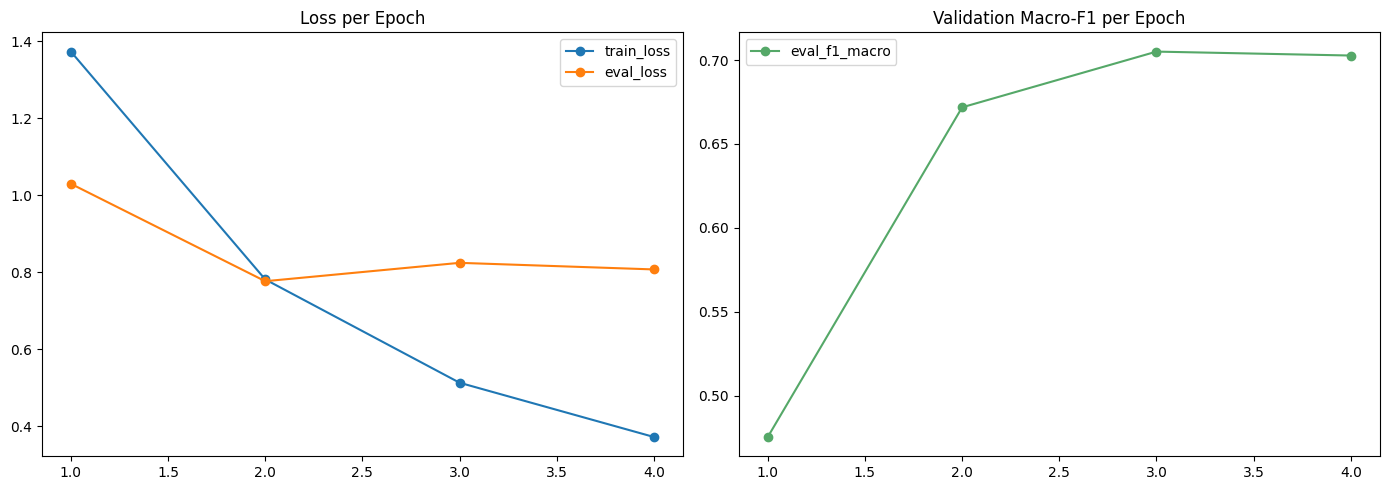

In [ ]:
log_history = trainer.state.log_history
train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e]
eval_loss = [(e["epoch"], e["eval_loss"]) for e in log_history if "eval_loss" in e]
eval_f1 = [(e["epoch"], e["eval_f1_macro"]) for e in log_history if "eval_f1_macro" in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if train_loss: axes[0].plot(*zip(*train_loss), label="train_loss", marker="o")
if eval_loss: axes[0].plot(*zip(*eval_loss), label="eval_loss", marker="o")
axes[0].set_title("Loss per Epoch"); axes[0].legend()
if eval_f1: axes[1].plot(*zip(*eval_f1), label="eval_f1_macro", marker="o", color="#55A868")
axes[1].set_title("Validation Macro-F1 per Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_TRAINING_DIR / "layer2_training_curves.png", dpi=150)
plt.show()

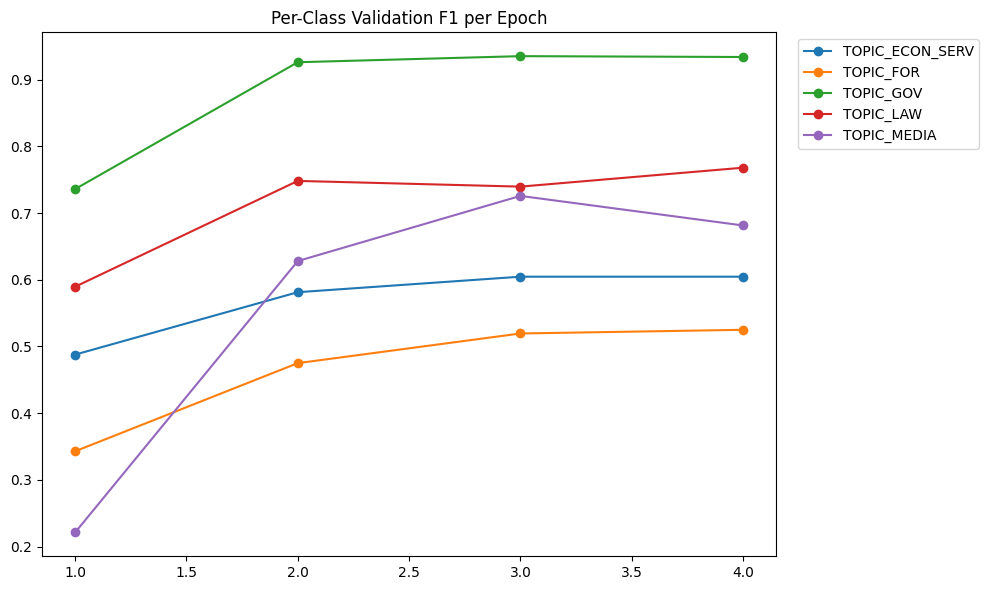

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for label in LAYER2_LABELS:
    key = f"eval_f1_{label}"
    series = [(e["epoch"], e[key]) for e in log_history if key in e]
    if series:
        ax.plot(*zip(*series), label=label, marker="o")
ax.set_title("Per-Class Validation F1 per Epoch")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_TRAINING_DIR / "layer2_per_class_f1_curves.png", dpi=150)
plt.show()

## 13. Save the Promoted Checkpoint

In [ ]:
best_model_dir = CHECKPOINTS_DIR / "best_model"
best_model_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(best_model_dir))
tokenizer.save_pretrained(str(best_model_dir))

metadata = {
    "base_model": MODEL_NAME, "num_labels": len(LAYER2_LABELS),
    "labels": LAYER2_LABELS, "max_seq_length": MAX_SEQ_LENGTH,
    "model_input_column": "text_clean",
    "best_metric": "f1_macro", "best_metric_value": trainer.state.best_metric,
    "class_weights_used": class_weights_dict,
    "taxonomy_note": "5-class merged taxonomy (TOPIC_ECON+TOPIC_SERV -> TOPIC_ECON_SERV), "
                       "documented scope decision -- see 01_data_preparation.ipynb Section 9",
    "random_seed": RANDOM_STATE, "train_rows": len(train_df), "val_rows": len(val_df),
}
with open(MODEL_DIR / "training_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to:", best_model_dir.resolve())
print("Best validation macro-F1:", trainer.state.best_metric)

Saved to: /content/drive/MyDrive/public-pulse-srilanka/models/layer2_topic/checkpoints/best_model
Best validation macro-F1: 0.7050123837778992


## 14. Validation Set Sanity Check

Not the final evaluation — `03_evaluation.ipynb` owns that.

In [ ]:
val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=-1)
val_labels = val_predictions.label_ids

print(classification_report(val_labels, val_preds, labels=list(range(len(LAYER2_LABELS))), target_names=LAYER2_LABELS, zero_division=0))

                 precision    recall  f1-score   support

TOPIC_ECON_SERV       0.53      0.70      0.60        37
      TOPIC_FOR       0.54      0.50      0.52        40
      TOPIC_GOV       0.95      0.92      0.94       950
      TOPIC_LAW       0.69      0.79      0.74        68
    TOPIC_MEDIA       0.68      0.78      0.73        58

       accuracy                           0.89      1153
      macro avg       0.68      0.74      0.71      1153
   weighted avg       0.89      0.89      0.89      1153



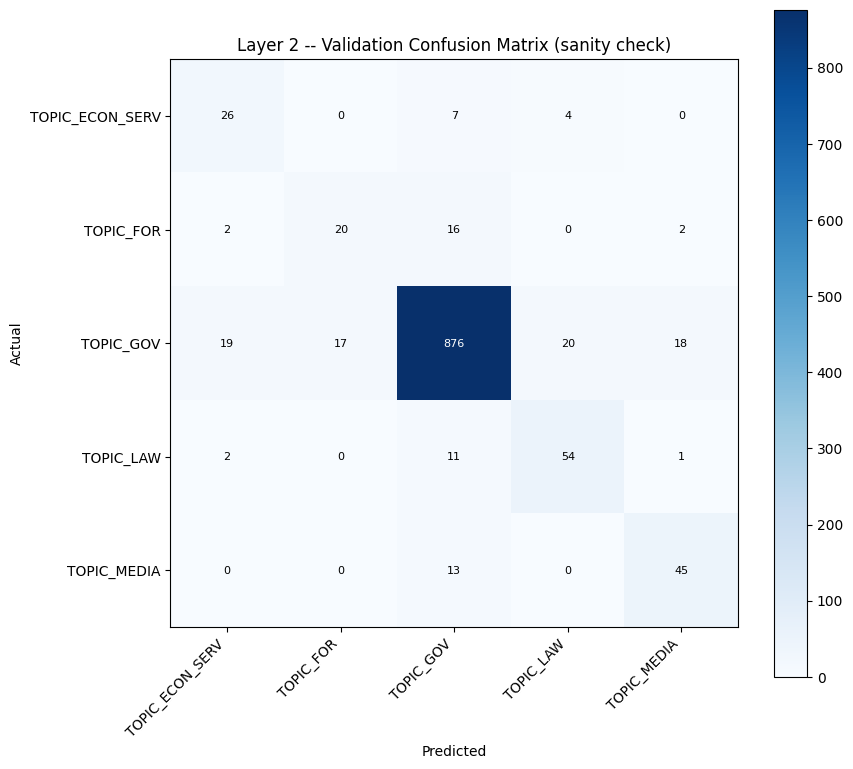

In [ ]:
cm = confusion_matrix(val_labels, val_preds, labels=list(range(len(LAYER2_LABELS))))
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LAYER2_LABELS))); ax.set_xticklabels(LAYER2_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LAYER2_LABELS))); ax.set_yticklabels(LAYER2_LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Layer 2 -- Validation Confusion Matrix (sanity check)")
for i in range(len(LAYER2_LABELS)):
    for j in range(len(LAYER2_LABELS)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i,j]>cm.max()/2 else "black", fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(RESULTS_CM_DIR / "layer2_validation_confusion_matrix.png", dpi=150)
plt.show()

## 15. Notebook Summary

### What was done
1. Colab environment configured (torchvision conflict avoided, transformers pinned, Drive mounted)
2. Loaded oversampled train + untouched val data, verified `text_clean` present and 5-class contract holds
3. Loaded correctly-computed class weights, built a `WeightedLossTrainer`
4. Fine-tuned `xlm-roberta-base` (5-way head) on `text_clean`, selected best checkpoint by macro-F1
5. Tracked per-class F1 through training
6. Saved checkpoint + full metadata including the taxonomy-merge note
7. Ran validation sanity check

### Key results
[Fill in after running: best validation macro-F1, per-class F1 for all 5 topics.]

## 16. Handover Notes — For `03_evaluation.ipynb`

**Load:** checkpoint from `models/layer2_topic/checkpoints/best_model/`, label map from
`models/layer2_topic/label_map.json` (5 classes, `TOPIC_ECON_SERV` merged, `NULL` excluded).

**Evaluate against `data/splits/layer2/test.csv` using `text_clean`, not `text_raw`.**

**Expected pattern:** `TOPIC_GOV` strong; `TOPIC_LAW`/`TOPIC_FOR`/`TOPIC_MEDIA`/
`TOPIC_ECON_SERV` should all be workable given the merge and oversampling — this layer
should not have a class performing near-zero, unlike Layer 4's known sarcasm limitation.
If any class does perform very poorly despite this, that's worth flagging as unexpected,
not dismissed as already-known.